# ALDIMI - EDA

Exploratory data analysis del dataset merged.

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

MERGED_PATH = Path('data') / 'merged' / 'Dataset_ALDIMI_Merged.csv'
df = pd.read_csv(MERGED_PATH)
print('Merged shape:', df.shape)
df.head()

Merged shape: (91250, 8)


,Fecha,ID_Insumo,Stock_Actual,Consumo_Diario,Lead_Time,Ocupacion_Albergue,Pacientes_Alto_Riesgo,Ocupacion_Total
0,2024-01-01,alimentos,592,21.62,14,0.68,0,1
1,2024-01-02,alimentos,575,14.90,14,0.00,0,1
2,2024-01-03,alimentos,540,23.85,14,0.00,0,1
3,2024-01-04,alimentos,516,25.20,14,1.69,1,1
4,2024-01-05,alimentos,495,10.34,14,0.00,0,1


In [6]:
print(df.info())
print('Missing values:')
print(df.isna().sum())
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Fecha                  91250 non-null  str    
 1   ID_Insumo              91250 non-null  str    
 2   Stock_Actual           91250 non-null  int64  
 3   Consumo_Diario         91250 non-null  float64
 4   Lead_Time              91250 non-null  int64  
 5   Ocupacion_Albergue     91250 non-null  float64
 6   Pacientes_Alto_Riesgo  91250 non-null  int64  
 7   Ocupacion_Total        91250 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 5.6 MB
None
Missing values:
Fecha                    0
ID_Insumo                0
Stock_Actual             0
Consumo_Diario           0
Lead_Time                0
Ocupacion_Albergue       0
Pacientes_Alto_Riesgo    0
Ocupacion_Total          0
dtype: int64


,Fecha,ID_Insumo,Stock_Actual,Consumo_Diario,Lead_Time,Ocupacion_Albergue,Pacientes_Alto_Riesgo,Ocupacion_Total
count,91250,91250,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0
unique,365,1,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-01-01,alimentos,NaN,NaN,NaN,NaN,NaN,NaN
freq,250,91250,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,471.522312,20.090923,7.984000,1.137708,0.013699,1.0
std,NaN,NaN,133.488002,5.016447,3.907929,1.374967,0.116237,0.0
min,NaN,NaN,168.000000,1.000000,2.000000,0.000000,0.000000,1.0
25%,NaN,NaN,370.000000,16.722500,4.000000,0.000000,0.000000,1.0
50%,NaN,NaN,461.000000,20.070000,8.000000,0.600000,0.000000,1.0
75%,NaN,NaN,564.000000,23.457500,11.000000,1.960000,0.000000,1.0


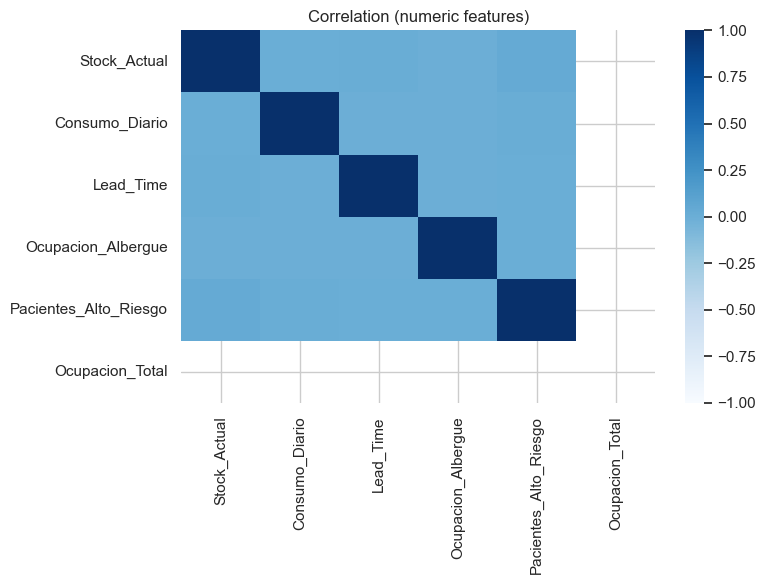

In [7]:
numeric = df.select_dtypes(include='number')
if not numeric.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric.corr(), cmap='Blues', vmin=-1, vmax=1)
    plt.title('Correlation (numeric features)')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns for correlation')

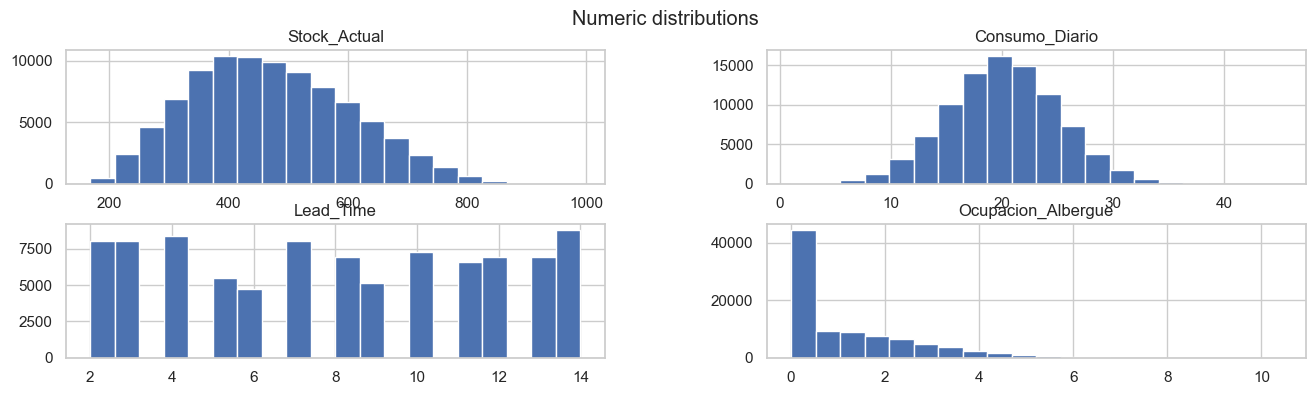

In [8]:
num_cols = numeric.columns.tolist()[:4]
if num_cols:
    df[num_cols].hist(bins=20, figsize=(4 * len(num_cols), 4))
    plt.suptitle('Numeric distributions')
    plt.show()
else:
    print('No numeric columns for distributions')

C:\Users\leona\AppData\Local\Temp\ipykernel_20256\2448335200.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


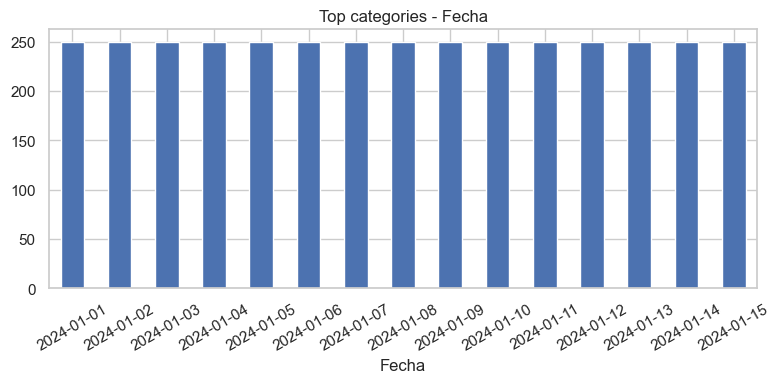

In [9]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    col = cat_cols[0]
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(15).plot(kind='bar')
    plt.title(f'Top categories - {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns for counts')